# Time-Frequency Analysis — Aurnhammer et al. (2021) Dataset

This notebook performs complex Morlet wavelet convolution (via MNE) on the
Aurnhammer 2021 semantic-mismatch EEG data to investigate the spectral properties
of the N400 (300-500 ms) and P600 (500-900 ms) ERP components.

**Conditions:** A (high lexical association / high expectancy) vs D (low lexical association / low expectancy)

**Dataset properties:**
- 26 active Ag/AgCl scalp electrodes
- 500 Hz sampling rate
- Bandpass filtered 0.01–30 Hz (→ max usable freq ≈ 30 Hz)
- Epochs: −200 ms to 1200 ms (target-word onset)
- Baseline already applied (−200 to 0 ms)

## 1 — Load Data & Build Epochs

-> Data loading code has been adapted from prior internship work conducted by the author on the same dataset.

In [ ]:
import pandas as pd
import numpy as np
import mne
import matplotlib.pyplot as plt

# 1. Load CSV 
df = pd.read_csv(
    ".../CAPExp.csv"
) # provide path to CAPExp.csv from Aurnhammer et al., 2021



# 2. Identify EEG channels 
meta_cols = [
    "ItemNum", "Condition", "Subject", "Timestamp", "TrialNum",
    "Cloze", "Cloze_Balanced", "Association", "Association_RC",
    "Association_MC", "Association_weighted", "RT", "ACC",
    "VEOG", "HEOG", "rcnoun", "rcverb"
]
eeg_channels = [c for c in df.columns if c not in meta_cols] #can be adjusted if only a subset of channels is needed
print(f"EEG channels ({len(eeg_channels)}): {eeg_channels}")



# 3. MNE Info object + standard 10-20 montage
sfreq = 500.0
info = mne.create_info(ch_names=eeg_channels, sfreq=sfreq, ch_types="eeg")

# Set standard 10-20 montage for topographic plotting
montage = mne.channels.make_standard_montage("standard_1020")
info.set_montage(montage, match_case=False)



# 4. Build Epochs per subject/condition 
def make_epochs(df_subj_cond):
    #convert a dataframe slice (one subject, one condition) into MNE EpochsArray -> other MNE functions applicable
    for trial, df_trial in df_subj_cond.groupby("TrialNum"):
        data = df_trial[eeg_channels].to_numpy().T  # (n_channels, n_times)
        epochs_data.append(data)
    epochs_data = np.array(epochs_data)
    events = np.array([[i, 0, 1] for i in range(len(epochs_data))]) #mandatory argument for mne.EpochsArray
    tmin = df_subj_cond["Timestamp"].iloc[0] / 1000.0
    epochs = mne.EpochsArray(
        epochs_data, info, events=events, 
        event_id={"stim": 1}, tmin=tmin
    )
    return epochs



# 5. Collect Epochs for conditions A & D 
all_epochs_A = []  # list of per-subject Epochs objects
all_epochs_D = []

for subj, df_sub in df.groupby("Subject"):
    conds = df_sub["Condition"].unique()
    if "A" in conds and "D" in conds: # check for both conditions to prevent imbalance of one condition
        all_epochs_A.append(make_epochs(df_sub[df_sub["Condition"] == "A"]))
        all_epochs_D.append(make_epochs(df_sub[df_sub["Condition"] == "D"]))

print(f"\nLoaded {len(all_epochs_A)} subjects.")
print(f"Example — Condition A, Subject 1: {all_epochs_A[0]}")
print(f"Example — Condition D, Subject 1: {all_epochs_D[0]}")

EEG channels (32): ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP9', 'CP5', 'CP1', 'CP2', 'CP6', 'TP10', 'P7', 'P3', 'Pz', 'P4', 'P8', 'PO9', 'O1', 'Oz', 'O2', 'PO10']
Not setting metadata
28 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
28 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
24 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
20 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
20 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
28 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
29 matchi

## 2 — Define TFR Parameters

In [ ]:
# Frequency vector: 2–30 Hz in 1-Hz steps
# Upper bound capped at 30 Hz because the data was low-pass filtered at 30 Hz.
freqs = np.arange(2, 31, 1) #1Hz not included because it cannot be applied to n_cycles = freqs/1.2

# Frequency-adaptive number of cycles:
# Lower freqs get fewer cycles -> better temporal resolution where it matters
# (e.g. 1 cycle at 2 Hz, 5 cycles at 10 Hz, 15 cycles at 30 Hz)

n_cycles = freqs / 1.2  # can be swapped out for 2 to attain the frequency/2 wavelet based topological maps as provided in the thesis


# Temporal decimation (1 = keep all time samples)
decim = 1

print(f"Frequencies: {freqs[0]}–{freqs[-1]} Hz  ({len(freqs)} bins)")
print(f"n_cycles  : {n_cycles[0]:.1f} at {freqs[0]} Hz  ->  {n_cycles[-1]:.1f} at {freqs[-1]} Hz")
print(f"Decimation: {decim}")

Frequencies: 2–30 Hz  (29 bins)
n_cycles  : 1.7 at 2 Hz  ->  25.0 at 30 Hz
Decimation: 1


## 3 — Compute TFRs 
per subject 


In [5]:
%%time

# Compute TFR for each subject in each condition
tfrs_A = []
tfrs_D = []

for i, (ep_A, ep_D) in enumerate(zip(all_epochs_A, all_epochs_D)):
    print(f"Subject {i+1}/{len(all_epochs_A)} ...", end=" ")

    #use_fft=True improved efficiency, average=True averages the results within subjects
    tfr_A = mne.time_frequency.tfr_morlet(
        ep_A, freqs=freqs, n_cycles=n_cycles,
        use_fft=True, return_itc=False,
        decim=decim, n_jobs=-1, average=True,
        verbose=False
    )
    tfr_D = mne.time_frequency.tfr_morlet(
        ep_D, freqs=freqs, n_cycles=n_cycles,
        use_fft=True, return_itc=False,
        decim=decim, n_jobs=-1, average=True,
        verbose=False
    )

    tfrs_A.append(tfr_A)
    tfrs_D.append(tfr_D)
    print("done")

print(f"\nTFR shape (per subject): {tfrs_A[0].data.shape}")
print("  (channels × frequencies × time points)")

Subject 1/40 ... NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


python(72603) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(72604) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(72605) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(72606) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(72607) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(72608) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(72609) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(72610) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(72611) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(72612) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
done
Subject 2/40 ... NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
done
Subject 3/40 ... NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
done
Subject 4/40 ... NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
done
Subject 5/40 ... NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
done
Subject 6/40 ... NOTE: tfr_morlet() is a legacy function. New code should use .

## 4 — Baseline Correction (dB)

Convert power to dB using mode= logratio

pre-stimulus period (−200 to 0 ms) is used as baseline.

In [6]:
#define pre-stimulus period
baseline = (-0.2, 0.0)

# Baseline-correct EACH subject first...
tfrs_A_bl = [tfr.copy().apply_baseline(baseline=baseline, mode="logratio") for tfr in tfrs_A] #percent,zscore,logratio
tfrs_D_bl = [tfr.copy().apply_baseline(baseline=baseline, mode="logratio") for tfr in tfrs_D]
# ...THEN grand-average the baseline-corrected TFRs
grand_tfr_A_bl = mne.grand_average(tfrs_A_bl)
grand_tfr_D_bl = mne.grand_average(tfrs_D_bl)

print("Baseline correction applied (mode='logratio' -> dB scale) and grand-averaged.")


Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode

## 7 — Plot: Topological Maps for N400 and P600 Windows


The key logic is: for each (time window × frequency band) cell, average the D−A power difference down to one value per electrode, then plot that as a topomap.


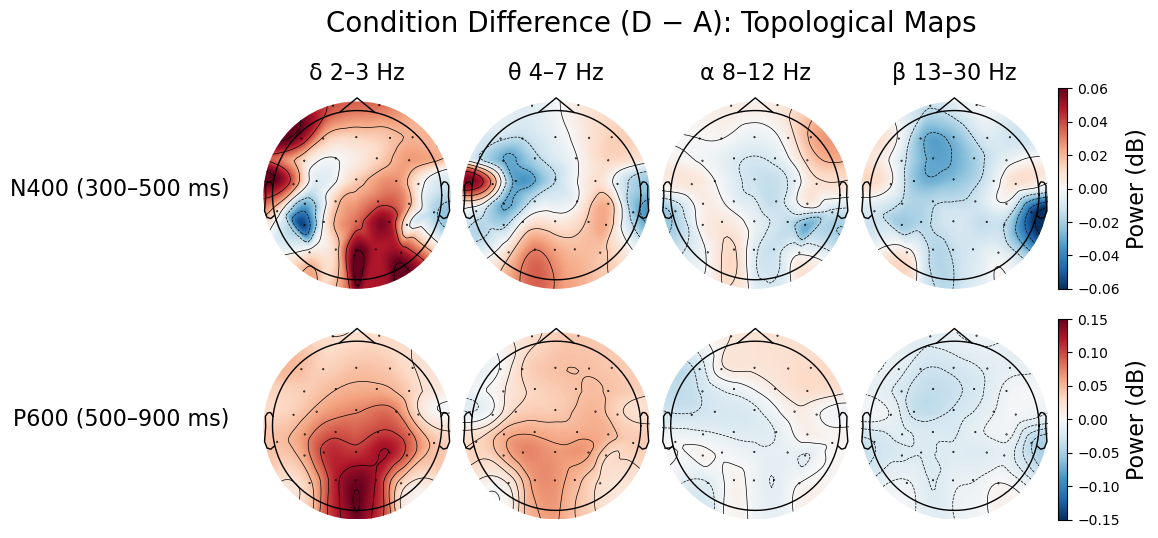

In [10]:
# This cell creates a grid of topographic maps showing WHERE on the scalp
# the power difference (Condition D minus Condition A) is strongest,
# broken down by frequency band (columns) and time window (rows).

import numpy as np
import matplotlib.gridspec as gridspec


# Step 1: dompute the difference TFR
# dopy the structure of the grand-average TFR for condition D
# then replace its data with the element wise difference D − A
# Result shape: (n_channels, n_freqs, n_times)
diff_tfr = grand_tfr_D_bl.copy()
diff_tfr.data = grand_tfr_D_bl.data - grand_tfr_A_bl.data



# Step 2: define the frequency bands and time windows for the grid
# Each frequency band becomes a COLUMN in the final plot.
# fmin/fmax define which frequency bins to average over.
freq_bands = [
    {"label": "δ 2–3 Hz",   "fmin": 2,  "fmax": 4},# Note: fmax = up to but not including
    {"label": "θ 4–7 Hz",   "fmin": 4,  "fmax": 8},
    {"label": "α 8–12 Hz",  "fmin": 8,  "fmax": 13},
    {"label": "β 13–30 Hz", "fmin": 13, "fmax": 31},
]

# Each time window becomes a ROW in the final plot.
# tmin/tmax define the temporal range to average over (in seconds).
time_windows = [
    {"label": "N400 (300–500 ms)", "tmin": 0.3, "tmax": 0.5},
    {"label": "P600 (500–900 ms)", "tmin": 0.5, "tmax": 0.9},
]

n_rows = len(time_windows)   # 2 rows (N400, P600)
n_cols = len(freq_bands)     # 4 columns (δ, θ, α, β)


# PASS 1: Extract the data for each cell of the grid

# For each (time_window, freq_band) combination, we average the
# difference TFR across the relevant time points AND frequency bins,
# leaving a 1-D vector of shape (n_channels,) — i.e., one scalar
# per electrode. This is what gets plotted on the topomap.
#
# We also compute a per-row color limit (row_vmax) so that all
# topomaps in the same row share a symmetric color scale.

diff_grid  = []   # 2D list: diff_grid[row][col] = (n_channels,) array
row_labels = []   # text labels for each row (e.g., "N400 (300–500 ms)")
col_labels = []   # text labels for each column (e.g., "δ 2–3 Hz")
row_vmax   = []   # max absolute value per row, used for color scaling

for r, tw in enumerate(time_windows):
    row_labels.append(tw["label"])
    row_data = []

    for c, fb in enumerate(freq_bands):
        # Only collect column labels from the first row (they're the same)
        if r == 0:
            col_labels.append(fb["label"])

        # Boolean masks selecting the time points and freq bins in this cell
        t_mask = (diff_tfr.times >= tw["tmin"]) & (diff_tfr.times <= tw["tmax"])
        f_mask = (diff_tfr.freqs >= fb["fmin"]) & (diff_tfr.freqs <= fb["fmax"])

        # Slice: (n_channels, freqs_in_band, times_in_window)
        # Then average over freq (axis=1) and time (axis=2)
        # result: (n_channels,), one value per electrode
        data_win = diff_tfr.data[:, f_mask, :][:, :, t_mask].mean(axis=(1, 2))
        row_data.append(data_win)

   
    row_vmax.append(max(np.abs(d).max() for d in row_data))
    diff_grid.append(row_data)


# PASS 2: Plot the grid of topomaps
# Layout: each row has n_cols topomap axes + 1 narrow colorbar axis.
# GridSpec lets us control the relative widths precisely.

fig = plt.figure(figsize=(2.4 * n_cols + 0.8, 2.8 * n_rows))
gs  = gridspec.GridSpec(
    n_rows, n_cols + 1,                       
    width_ratios=[1] * n_cols + [0.05],       
    wspace=0.05, hspace=0.15
)

# Override the auto-computed row_vmax with manually chosen values
# to get a consistent, publication-ready color range.
row_vmax = [0.06, 0.15]

for r in range(n_rows):
    vmax = row_vmax[r]         # symmetric limits: colorbar goes −vmax to +vmax
    im = None                  # will hold the last topomap image (for colorbar)

    for c in range(n_cols):
        ax = fig.add_subplot(gs[r, c])

        # Plot a single topomap: the (n_channels,) vector mapped onto
        # the scalp using electrode positions from diff_tfr.info.
        # RdBu_r: red = positive (D > A), blue = negative (A > D).
        im, _ = mne.viz.plot_topomap(
            diff_grid[r][c], diff_tfr.info,
            axes=ax, show=False,
            vlim=(-vmax, vmax), cmap="RdBu_r"
        )

        # Column titles (frequency bands) — only on the top row
        if r == 0:
            ax.set_title(col_labels[c], fontsize=16, pad=6)

        # Row labels (time windows) — only on the leftmost column,
        # placed just outside the axis using a text annotation.
        if c == 0:
            ax.text(-0.18, 0.5, row_labels[r],
                    transform=ax.transAxes, fontsize=16,
                    va='center', ha='right')

    # Add one colorbar per row in the rightmost column of the grid.
    # It inherits the vlim from the last topomap plotted (im).
    cbar_ax = fig.add_subplot(gs[r, -1])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("Power (dB)", size=16)

# Overall figure title
fig.suptitle("Condition Difference (D − A): Topological Maps",
             fontsize=20, y=1.02)
plt.show()
